# Darstellung von Funktionen mit mehreren Variablen


## Übungsblatt


In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Aufgabe 1


Betrachten wir die Funktion

$$ g(x, y) = x \cdot e^{- x^2 - y^2} + \tfrac{1}{6}y$$

<!-- $$ g(x, y) = \left(x^2 + 1.5 y^3\right) e^{- x^2 - y^2} $$ -->

im Bereich $x, y \in[-2,2]$.


#### 1.1 Höhenlinien

Stelle die Höhenlinien der Funktion dar. Probiere unterschiedliche Werte für die Anzahl der Höhenlinien aus. Schreibe die Höhenlinien mit [`plt.clabel`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.clabel.html) an.


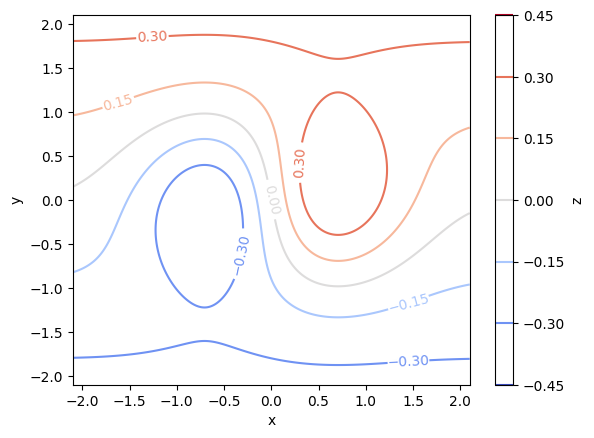

In [2]:
# Aufgabe 1.1


def g(x, y):
    return x * np.exp(-(x**2) - y**2) + y / 6


n = 500
x = np.linspace(-2.1, 2.1, n)
y = np.linspace(-2.1, 2.1, n)
X, Y = np.meshgrid(x, y)
Z = g(X, Y)

cs = plt.contour(X, Y, Z, cmap="coolwarm")
plt.clabel(cs)
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar(label="z")
plt.show()

#### 1.2 Isokonturlinien

Stelle Isokonturlinien für a) konstante $x\in\{-2,1,0,1,2\}$ und b) konstante $y\in\{-2,1,0,1,2\}$ dar (mit korrekten Achsenbeschriftungen).

Hinweis: Die Funktionsgleichung von $z=g(x,y)$ kann hier nicht analytisch nach $y$ aufgelöst werden. Also kann man nicht für eine Serie von $x$-Werten die
Du kannst dazu entweder mehrere Graphen mit `plt.plot` erstellen oder auch `plt.contour` nutzen.


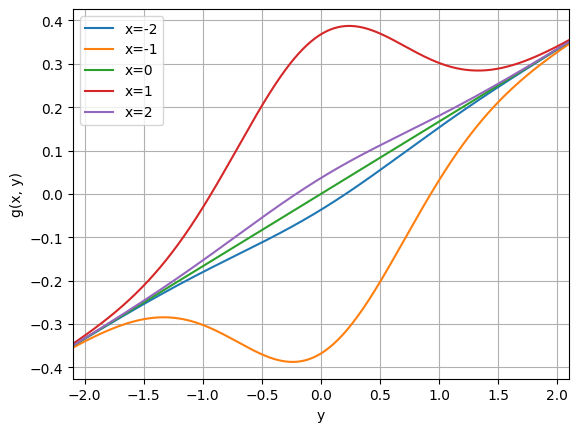

In [3]:
# Aufgabe 1.2 a)
levels = [-2, -1, 0, 1, 2]

# Lösung mit Plot
for x_level in levels:
    plt.plot(y, g(x_level, y), label=f"x={x_level}")
plt.xlim(y.min(), y.max())
plt.xlabel("y")
plt.ylabel("g(x, y)")
plt.legend()
plt.grid()
plt.show()

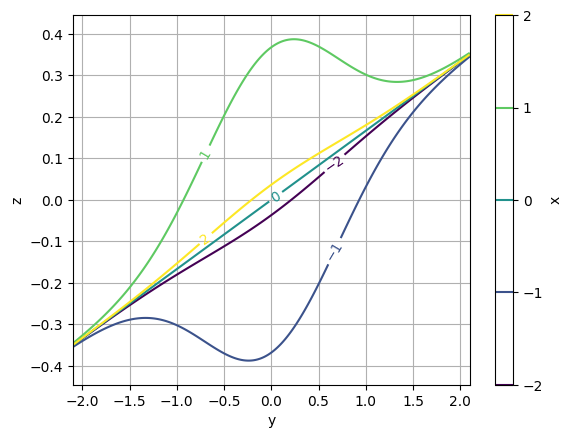

In [4]:
# Lösung mit Contour
cs = plt.contour(Y, Z, X, levels=levels)
plt.clabel(cs)
plt.xlabel("y")
plt.ylabel("z")
plt.colorbar(label="x")
plt.grid()
plt.show()

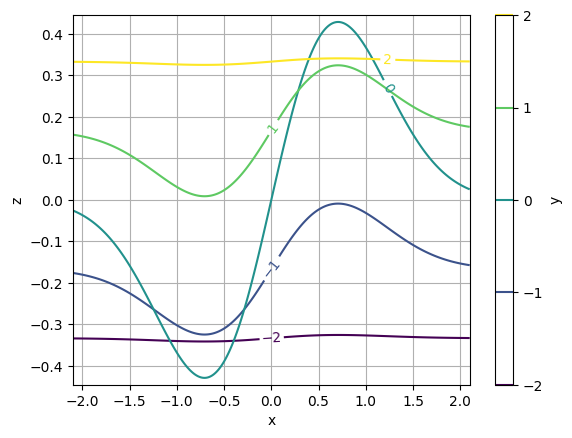

In [5]:
# Aufgabe 1.2 b)

cs = plt.contour(X, Z, Y, levels=levels)
plt.clabel(cs)
plt.xlabel("x")
plt.ylabel("z")
plt.colorbar(label="y")
plt.grid()
plt.show()

#### 1.3 Gefüllte Höhenlinien

Erstelle ein Höhenliniendiagramm mit gefüllten Flächen. Nutze dazu die Funktion [`plt.contourf`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contourf.html) mit vielen Levels.

Stelle darüber auch noch eine kleinere Anzahl Höhenlinien mit [`plt.contour`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contour.html) dar.


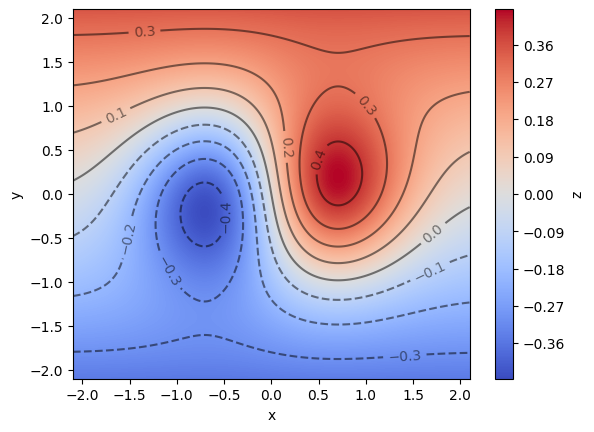

In [6]:
# Aufgabe 1.3

plt.contourf(X, Y, Z, levels=1000, cmap="coolwarm")
plt.colorbar(label="z")
plt.xlabel("x")
plt.ylabel("y")
cs = plt.contour(X, Y, Z, levels=10, colors="black", alpha=0.5)
# Der alpha Wert bestimmt die Transparenz (0 = transparent, 1 = opak)
plt.clabel(cs)
plt.show()

#### 1.4 Alles in einem Diagramm

Erstelle mit [`plt.subplots()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) ein Diagramm mit $2 \times 2$ Koordinatenachsen. Darin sollen unterschiedliche Darstellungen der Funktion $g(x,y)$ aus Aufgabe 1 eingefügt werden:
-	unten links die Höhenlinien in der x-y-Ebene 
-	oben links die Isolinien für konstante y, mit x in der horizontalen und z in der vertikalen Achse
-	unten rechts die Isolinien für konstante x, mit z in der horizontalen und y in der vertikalen Achse
mit der Methode [`ax.set_axis_off()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_axis_off.html) kannst du die leeren Koordinatenachsen oben rechts entfernen.

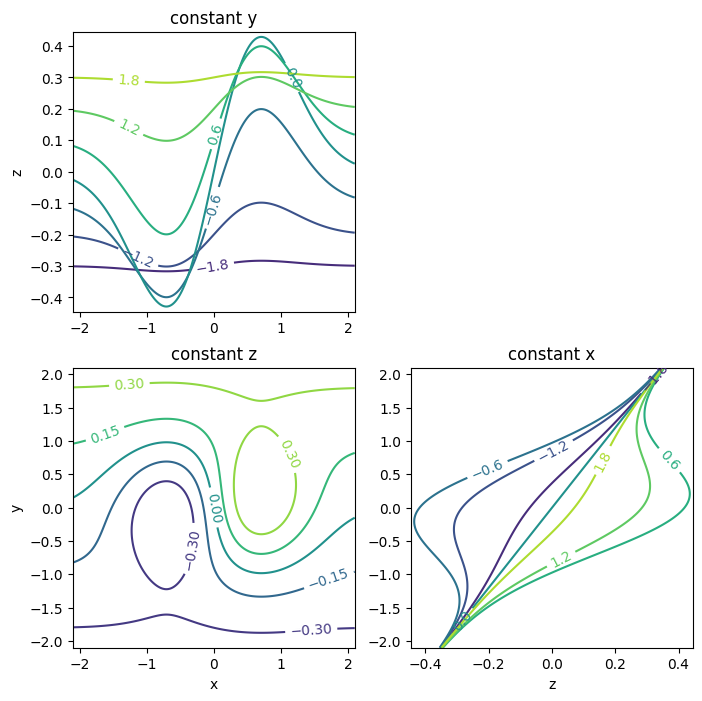

In [7]:
# Aufgabe 1.4

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 8))

# Unten links: konstante z
cs = ax3.contour(X, Y, Z)
cs.clabel(inline=True, fontsize=10)
ax3.set_title("constant z")
ax3.set_xlabel("x")
ax3.set_ylabel("y")

# Unten rechts: konstante x
cs = ax4.contour(Z, Y, X)
cs.clabel(inline=True, fontsize=10)
ax4.set_title("constant x")
ax4.set_xlabel("z")
# ax4.set_ylabel("y")

# Oben links: konstante y
cs = ax1.contour(X, Z, Y)
cs.clabel(inline=True, fontsize=10)
ax1.set_title("constant y")
# ax1.set_xlabel("x")
ax1.set_ylabel("z")

# Oben rechts: gar nichts
ax2.set_axis_off()

plt.show()

### Aufgabe 2


#### 2.1 Daten einlesen

In der Datei `xyz_data.csv` befinden sich Messwerte, wobei $z$ als Funktion von $x$ und $y$ interpretiert werden kann.

Lies die Daten ein, entpacke sie in drei Arrays `x`, `y` und `z`. Wie viele Messpunkte sind es?


In [8]:
# Aufgabe 2.1

x, y, z = np.loadtxt("xyz_data.csv", delimiter=",", skiprows=2).T

x.shape, y.shape, z.shape

((900,), (900,), (900,))

#### 2.2 Höhenliniendiagramm

-   Erstelle mit den eingelesenen Daten ein Höhenliniendiagramm mit gefüllten Flächen und vielen Levels.
-   Beschrifte die Achsen und füge die Farbskala mit entsprechender Beschriftung hinzu.
-   Lege darüber nochmals eine kleinere Anzahl Höhenlinien ohne Flächenfüllung und beschrifte die Linien mit deren $z$-Werten.
-   Schau dir die [Dokumentation zu Farbskalen in Matplotlib](https://matplotlib.org/stable/users/explain/colors/colormaps.html) an und probiere für den gefüllten Contour-Plot verschiedene Farbskalen aus.


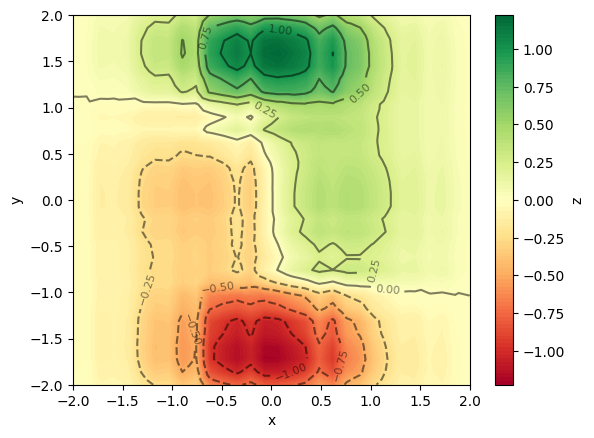

In [9]:
# Aufgabe 2.2

plt.tricontourf(x, y, z, levels=100, cmap="RdYlGn")
plt.colorbar(label="z")
cs = plt.tricontour(x, y, z, levels=10, colors="black", alpha=0.5)
plt.clabel(cs, fontsize=8)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

#### 2.3 Sampling-Punkte

Stelle in der Ebene der unabhängigen Variablen alle Punkte dar, an denen die Funktion vermessen wurde.


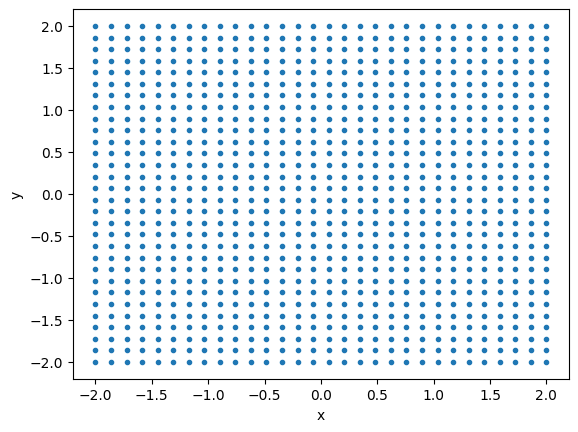

In [10]:
# Aufgabe 2.3

plt.plot(x, y, ".")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### Aufgabe 3

Wähle eine der ["Test-Functions for Optimization"](https://en.wikipedia.org/wiki/Test_functions_for_optimization) aus und stelle die Höhenlinien davon dar, wie sie auch auf der Wikipedia-Seite ersichtlich sind.

**Hinweis:** Die $z$-Skala ist in gewissen Fällen logarithmiert, siehe genau hin. Um dies auch hinzukriegen, kannst du

-   entweder die Funktionswerte vor dem Darstellen zur Basis 10 logarithmieren (`np.log10`),
-   oder dieses Beispiel adaptieren, um eine logarithmierte Skala für die Levels zu erhalten: [Contourf and log color scale](https://matplotlib.org/stable/gallery/images_contours_and_fields/contourf_log.html).


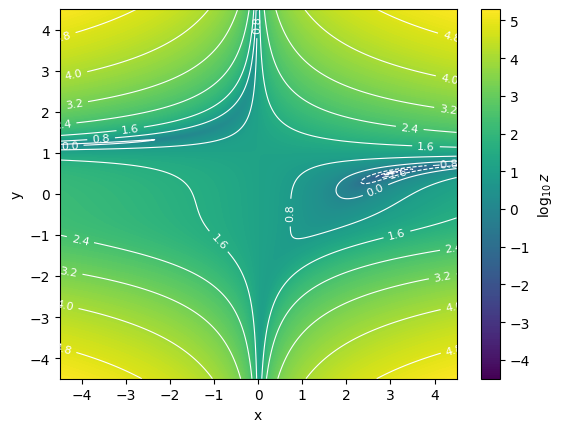

In [11]:
### Aufgabe 2


def Beale(x, y):
    return (
        (1.5 - x + x * y) ** 2
        + (2.25 - x + x * y**2) ** 2
        + (2.625 - x + x * y**3) ** 2
    )


n = 1000
x = y = np.linspace(-4.5, 4.5, n)
X, Y = np.meshgrid(x, y)
Z = Beale(X, Y)

# Statt eine logarithmische Skala zu verwenden, könnten
# einfach die Funktionswerte logarithmieren und dann
# die Höhenlinien davon darstellen:

lgZ = np.log10(Z)

plt.contourf(X, Y, lgZ, 200)
plt.colorbar(label=r"$\log_{10}z$")
cs = plt.contour(X, Y, lgZ, levels=15, colors="white", linewidths=0.8)
plt.clabel(cs, fontsize=8)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

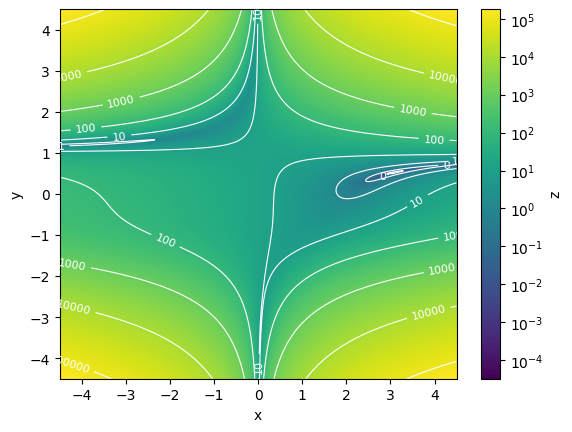

In [12]:
# Um wirklich eine logarithmische Skala für die Höhenlinien
# und die Farbgebung zu erhalten, muss man etwas mehr Aufwand
# betreiben, siehe
# https://matplotlib.org/stable/gallery/images_contours_and_fields/contourf_log.html

from matplotlib.ticker import LogLocator

levels_fine = np.logspace(lgZ.min(), lgZ.max(), 200)
decades = 10 ** np.arange(np.floor(lgZ.min()), np.ceil(lgZ.max()))

plt.contourf(X, Y, Z, levels=levels_fine, locator=LogLocator())
plt.colorbar(label="z", ticks=decades)
cs = plt.contour(
    X, Y, Z, levels=decades, locator=LogLocator(), colors="white", linewidths=0.8
)
plt.clabel(cs, fontsize=8)
plt.xlabel("x")
plt.ylabel("y")
plt.show()